In [1]:
from pathlib import Path
from tabulate import tabulate
from itertools import product

from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr

In [2]:
project_dir = Path("K:/PythonWork/downscaling/Kaya_downscaling")
#project_dir = Path("Z:/cold_data_storage/users/roelfsemam/temp")

In [3]:
profiles = ["base_run", "sensitivity_3", "sensitivity_4", "sensitivity_5"]
models = ["IMAGE_ScenarioMIP", "REMIND_ScenarioMIP"]
model_versions = ["IMAGE 3.4", "REMIND-MAgPIE 3.5-4.11"]
scenarios = ["Medium", "Low"]
conv_years = ["2150", "2120", "2180"]
SSPs = ["SSP2", "SSP1"]
harms = ["harmonised", "unharmonised"]
dir = project_dir / "data" / "processed"

#scenario_run = "IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2150_net"
#em_file = "Emissions_CO2_Excl_shipping_aviation_AFOLU_unharmonised_SSP2.nc"

In [4]:
em_file = f"Emissions_CO2_Excl_shipping_aviation_AFOLU_unharmonised_SSP2.nc"
scenario_run = f"{models[0]}_{model_versions[0]}_{scenarios[0]} - {SSPs[0]}_conv_year_{conv_years[0]}_net"
print(scenario_run)
xr_emissions = xr.open_dataset(Path(dir / profiles[0] / scenario_run / em_file))
xr_emissions

IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2150_net


<xarray.Dataset> Size: 674MB
Dimensions:                                     (time: 12, y: 1800, x: 3600)
Coordinates:
  * x                                           (x) float64 29kB -179.9 ... 1...
  * y                                           (y) float64 14kB 89.95 ... -8...
  * time                                        (time) int64 96B 2020 ... 2100
    region_number                               (y, x) int64 52MB ...
    spatial_ref                                 int64 8B ...
Data variables:
    Emissions_CO2_Excl_shipping_aviation_AFOLU  (time, y, x) float64 622MB ...

In [5]:
# with pathlib find emfile in the directoy profile (from profiles) and scenario_run, open it, make it into a dataframe, and collect it into a general dataframe
df_total_runs = pd.DataFrame()
col_distinct = "profile, model, model_version, SSP, conv_year"
for profile, model, model_version, scenario, conv_year, SSP, harm in product(profiles, models, model_versions, scenarios, conv_years, SSPs, harms):
    scenario_run = f"{model}_{model_version}_{scenario} - {SSP}_conv_year_{conv_year}_net"
    em_file = f"Emissions_CO2_Excl_shipping_aviation_AFOLU_{harm}_{SSP}.nc"
    em_dir = Path(dir / profile / scenario_run)
    #print(em_dir)
    if em_dir.exists():
        print(f"Processing {em_dir}")
        xr_emissions = xr.open_dataset(em_dir / em_file)
        global_per_year = xr_emissions["Emissions_CO2_Excl_shipping_aviation_AFOLU"].sum(dim=["y", "x"])
        df_em = global_per_year.to_dataframe().reset_index()

        df_em.drop(columns=["spatial_ref"], inplace=True, errors="ignore")
        df_em["scenario"] = scenario
        df_em["harmonised"] = (harm == "harmonised")

        df_em[col_distinct] = f"{profile}, {model}, {model_version}, {SSP}, {conv_year}"
        df_em["profile"] = profile
        df_em["model"] = model
        df_em["model_version"] = model
        df_em["SSP"] = SSP
        df_em["conv_year"] = conv_year
        df_em.rename(columns={"time": "year"}, inplace=True)

        df_total_runs = pd.concat([df_total_runs, df_em])

df_total_runs.to_csv(project_dir / "data" / "check" / "check_results.csv", index=False, sep=";")

Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2150_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2150_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP1_conv_year_2150_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP1_conv_year_2150_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2120_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2120_net
Processing K:\PythonWork\downscaling\Kaya_downscaling\data\processed\base_run\IMAGE_ScenarioMIP_IMAGE 3.4_Medium - SSP2_conv_year_2180_net
Processing K:\PythonWork\do

In [6]:
cols_distinct = df_total_runs[col_distinct].unique()
print(type(cols_distinct))
cols = list(cols_distinct)[::-1]
df_total_runs[col_distinct] = pd.Categorical(df_total_runs[col_distinct], categories=cols, ordered=True)

<class 'numpy.ndarray'>


In [7]:
mask = df_total_runs["harmonised"] == True
df_total_runs_check = df_total_runs[mask]
count = df_total_runs_check.groupby(["scenario", "year"]).size()
count = pd.DataFrame(count).reset_index()
count.rename(columns={0: "count"}, inplace=True)
count[count["year"] == 2020]

,scenario,year,count
0,Low,2020,8
12,Medium,2020,8


C:\Users\roelfsemam\AppData\Local\Temp\20\ipykernel_12924\1297398870.py:1: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  g = sns.relplot(data=df_total_runs, x="year", y="Emissions_CO2_Excl_shipping_aviation_AFOLU",


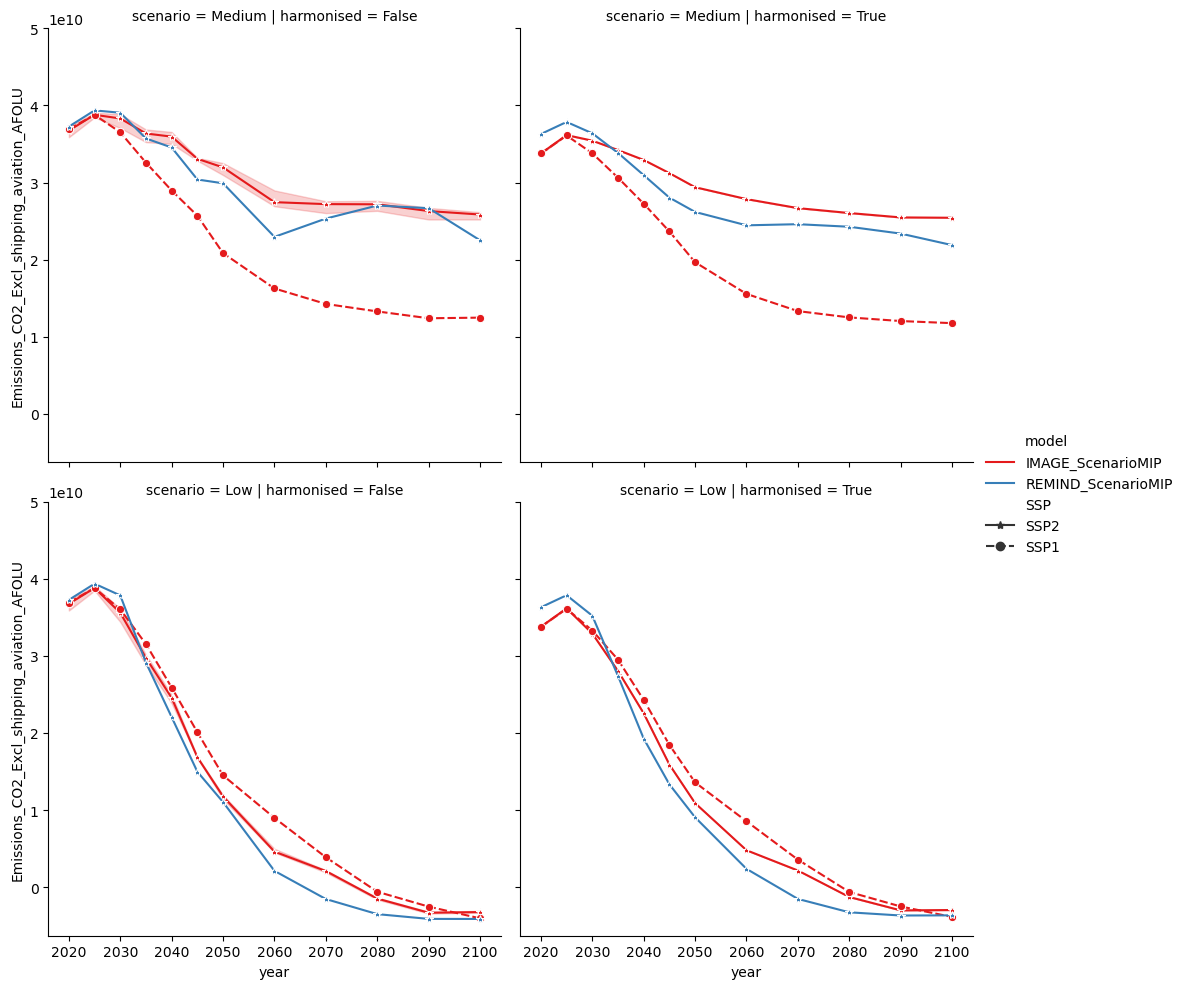

In [8]:
g = sns.relplot(data=df_total_runs, x="year", y="Emissions_CO2_Excl_shipping_aviation_AFOLU",
            col="harmonised", row="scenario", hue="model", style="SSP", markers=["*", "o", "s"], kind="line", palette="Set1",errorbar=lambda x: (x.min(), x.max()))
g.set(ylim=(None, 5e10))

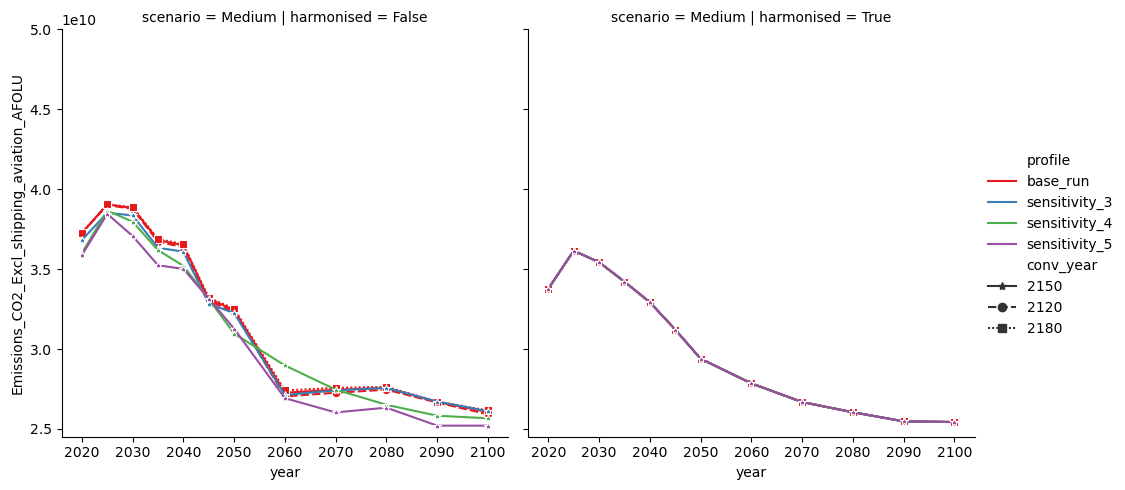

In [9]:
mask_selection = (df_total_runs["model"] == "IMAGE_ScenarioMIP") & (df_total_runs["scenario"] == "Medium") & (df_total_runs["SSP"] == "SSP2")
df_total_runs_selection = df_total_runs[mask_selection]
g = sns.relplot(data=df_total_runs_selection, x="year", y="Emissions_CO2_Excl_shipping_aviation_AFOLU",
            col="harmonised", row="scenario", hue="profile", style="conv_year", markers=["*", "o", "s"], kind="line", palette="Set1")
g.set(ylim=(None, 5e10))

In [10]:
df_print = df_total_runs.pivot(index="year", columns="run", values="Emissions_CO2_Excl_shipping_aviation_AFOLU")
#print(tabulate(df_print, headers="keys", tablefmt="grid", showindex=False, floatfmt=",.1f", intfmt=","))
save_dir = project_dir / "data" / "check" / scenario_run
save_dir.mkdir(parents=True, exist_ok=True)
print(save_dir)
df_print.to_csv(save_dir / f"check_results_{scenario_run}.csv", index=True, float_format="%.1f", sep=";")

KeyError: 'run'